In [1]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
stock = yf.Ticker('NET')
# stock = yf.Ticker('WIX')
# stock = yf.Ticker('NVDA')

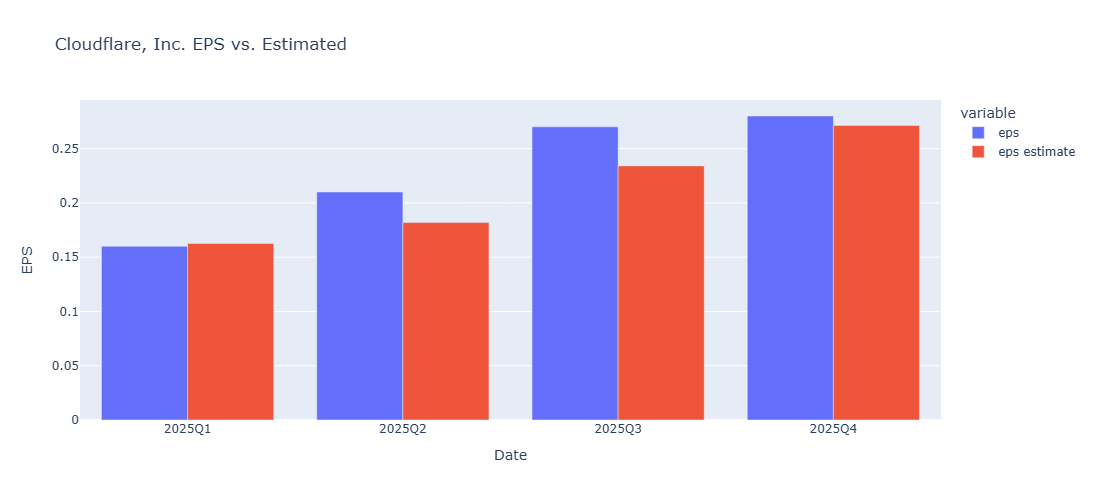

In [3]:
def actual_vs_estimate(ticker):
    historic = ticker.get_earnings_history()
    df_historic = pd.DataFrame(historic)
    # Convert to quarters for a cleaner looking xaxis
    df_historic.index = df_historic.index.to_period('Q').astype(str)
    df_historic = df_historic.reset_index()
    df_historic = df_historic.rename(columns={'epsActual': 'eps', 'epsEstimate': 'eps estimate'})
    historic_bar = px.bar(df_historic, x='quarter', y=['eps', 'eps estimate'],
                          title=f'{ticker.info['shortName']} EPS vs. Estimated', barmode='group', height=500)
    historic_bar.update_layout(xaxis_title='Date', yaxis_title='EPS')
    
    return df_historic, historic_bar
history, chart = actual_vs_estimate(ticker=stock)
chart

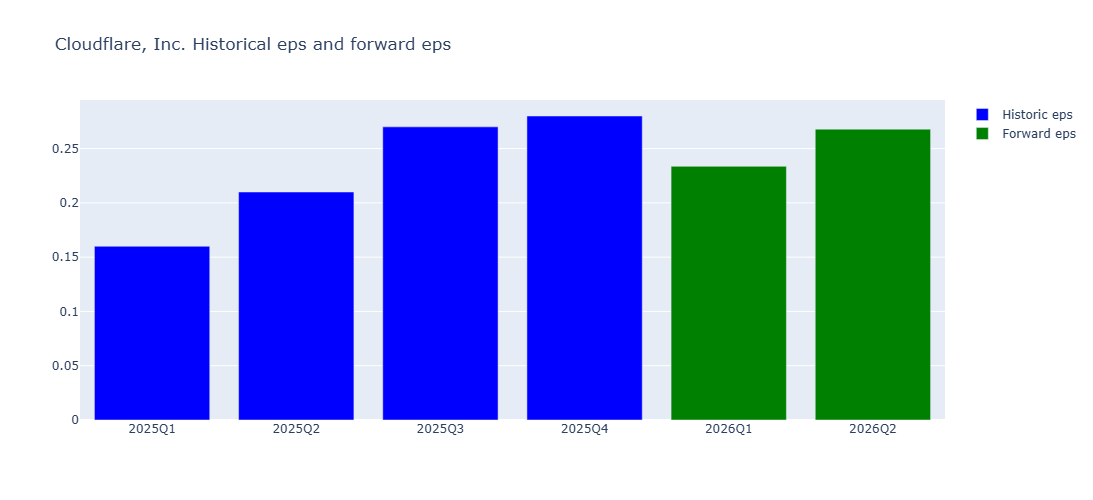

In [4]:
def future_eps(ticker, eps_previous):
    # Obtain only previous eps data from history dataframe
    eps_previous = eps_previous[['quarter', 'eps']]  
    # Obtain eps estimates for the next 2 quarters
    estimates = stock.get_earnings_estimate()
    estimates = estimates.reset_index()
    estimates = estimates.rename(columns={'period': 'quarter', 'avg': 'eps'})
    eps_estimate = estimates[['quarter', 'eps']]
    # Drop eps year data
    eps_estimate = eps_estimate.drop([2, 3])
    # Clean up eps_estimate column data
    eps_estimate.loc[0, 'quarter'] = '2026Q1'
    eps_estimate.loc[1, 'quarter'] = '2026Q2'
    # Combine historical and estimates
    # eps_combined = pd.concat([eps, eps_estimate], ignore_index=True)

    # Plot data
    eps_bar = go.Figure()
    eps_bar.add_trace(go.Bar(x=eps_previous.quarter, y=eps_previous.eps,
                             marker_color='blue', name='Historic eps'))
    eps_bar.add_trace(go.Bar(x=eps_estimate.quarter, y=eps_estimate.eps,
                             marker_color='green', name='Forward eps'))
    eps_bar.update_layout(title_text=f'{ticker.info['shortName']} Historical eps and forward eps', 
                         height=500)
    
    return eps_bar
future_eps(ticker=stock, eps_previous=history)

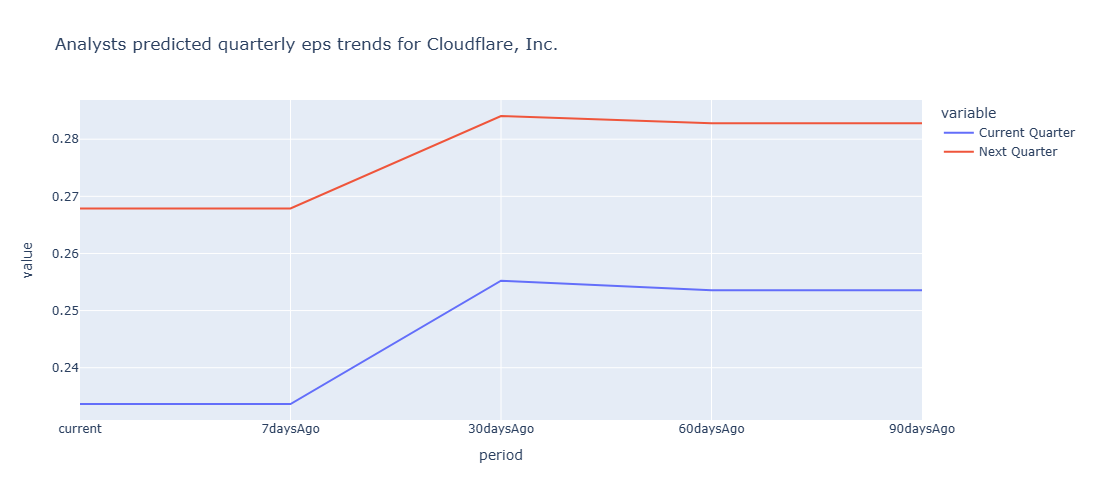

In [5]:
def get_eps_trends(ticker):
    trends = ticker.get_eps_trend()
    trends_tran = trends.transpose()
    trends_tran = trends_tran.rename(columns={'0q': 'Current Quarter', 
                                          '+1q': 'Next Quarter', 
                                          '0y': 'Current Year',
                                          '+1y': 'Next Year',}).reset_index(names='period')
    quarter_trend = trends_tran[['period', 'Current Quarter', 'Next Quarter']]
    yearly_trend = trends_tran[['period', 'Current Year', 'Next Year']]

    quarter_line = px.line(quarter_trend, x='period', y=['Current Quarter', 'Next Quarter'], 
                           height=500, title=f'Analysts predicted quarterly eps trends for {ticker.info['shortName']}')

    year_line = px.line(yearly_trend, x='period', y=['Current Year', 'Next Year'],
                        height=500, title=f'Analysts predicted yearly eps trends for {ticker.info['shortName']}')

    return quarter_line, year_line
quarter_trend_chart, year_trend_chart = get_eps_trends(ticker=stock)
quarter_trend_chart

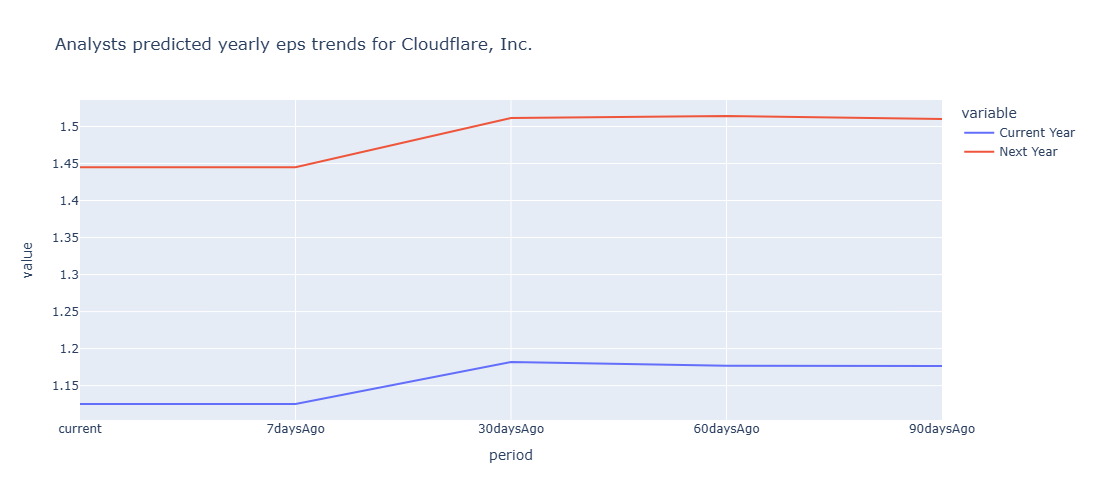

In [6]:
year_trend_chart

In [7]:
eps = stock.get_earnings_history()
eps

,epsActual,epsEstimate,epsDifference,surprisePercent
quarter,,,,
2025-03-31,0.16,0.16254,-0.00,-0.0156
2025-06-30,0.21,0.18181,0.03,0.1551
2025-09-30,0.27,0.23406,0.04,0.1536
2025-12-31,0.28,0.27129,0.01,0.0321


In [8]:
info = stock.info
info

{'address1': '101 Townsend Street',
 'city': 'San Francisco',
 'state': 'CA',
 'zip': '94107',
 'country': 'United States',
 'phone': '888 993 5273',
 'website': 'https://www.cloudflare.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Cloudflare, Inc. operates as a cloud services provider that delivers a range of services to businesses worldwide. The company provides a cloud-based security solution to secure a range of combination of platforms, including public and private cloud, on-premises, software-as-a-service applications, and Internet of things (IoT) devices; and application security products comprising web application firewall, bot management, distributed denial of service mitigation, API security, SSL/TLS encryption, client-side security, and security center products. It also offers app

In [9]:
trailing_eps = info['trailingEps']
eps_trailing_12_months = info['epsTrailingTwelveMonths']
epsCurrentYear = info['epsCurrentYear']
forward_eps = info['forwardEps']
try:
    trailing_PE = info['trailingPE']
except KeyError:
    print('No trailing P/E data found')
forward_PE = info['forwardPE']

No trailing P/E data found


In [10]:
print(f'Trailing EPS: {trailing_eps}')
print(f'Trailing 12 month eps: {eps_trailing_12_months}')
print(f'Current year predicted eps: {epsCurrentYear}')
print(f'Foward eps: {forward_eps}')
try:
    print(f"Trailing PE: {trailing_PE}")
except NameError:
    print('No traling P/E data found')
print(f'Forward PE: {forward_PE}')

Trailing EPS: -0.29
Trailing 12 month eps: -0.29
Current year predicted eps: 1.12522
Foward eps: 1.44486
No traling P/E data found
Forward PE: 132.64261
